# 🧠 AI CRM Brain — Sprint 2
## Phase 1: Exploratory Data Analysis (EDA)

---

Welcome! This notebook walks you through a **complete EDA** of the CRM Deals dataset.

**What we have:**

| Column | Type | Description |
|---|---|---|
| `Deal_ID` | Text | Unique identifier for each deal |
| `Owner_Name` | Text | Sales rep who owns the deal |
| `Account_Name` | Text | Company/client name |
| `Stage` | Text | 🎯 **Our target** — Won / Lost / Engaging / Prospecting |
| `Amount` | Number | Deal value in USD |
| `Closing_Date` | Date | Expected or actual close date |

**Goal:** Understand the data deeply before we build any ML model.

---


## Step 1 — Import Libraries

We only need a few libraries. Here's what each one does:
- **pandas** → loads and manipulates our data (like Excel, but in Python)
- **numpy** → math helpers
- **matplotlib** → draws charts
- **seaborn** → prettier charts built on top of matplotlib


In [1]:
# Run this cell first — it sets everything up

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Make all charts look clean and consistent
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# One consistent colour for each stage — used in every chart below
STAGE_COLOURS = {
    'Won':         '#16A34A',   # green
    'Lost':        '#DC2626',   # red
    'Engaging':    '#2563EB',   # blue
    'Prospecting': '#D97706',   # amber
}

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


---
## Step 2 — Load the Data

You can load your data in **two ways**.  
Choose the one that matches your setup and run only that cell.


### Option A — Load from a CSV file
Use this if you exported the data to a `.csv` file.


In [2]:
# ── Option A: Load from CSV ──────────────────────────────────────
# Change 'deals.csv' to the actual path of your file

df = pd.read_csv('/mnt/d/01_Projects/NLP/AI CRM Brain/AI-CRM-Brain/data/raw data/sales_pipeline.csv')

print(f"✅ Data loaded from CSV!")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")


✅ Data loaded from CSV!
   Rows    : 8,800
   Columns : 8


### Option B — Load from PostgreSQL
Use this if the data lives in your database.


In [ ]:
# # ── Option B: Load from PostgreSQL ───────────────────────────────
# # Make sure your .env file has: POSTGRES_USER, POSTGRES_PASSWORD, POSTGRES_DB

# import os
# from sqlalchemy import create_engine
# from dotenv import load_dotenv

# load_dotenv()

# engine = create_engine(
#     f"postgresql+psycopg2://"
#     f"{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
#     f"@{os.getenv('POSTGRES_HOST', 'localhost')}:5432/{os.getenv('POSTGRES_DB')}"
# )

# df = pd.read_sql("SELECT * FROM zoho_deals;", con=engine)

# print(f"✅ Data loaded from PostgreSQL!")
# print(f"   Rows    : {len(df):,}")
# print(f"   Columns : {df.shape[1]}")


### Parse the Date Column
We tell pandas that `Closing_Date` is a date, not just text.


In [4]:
df.columns

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value'],
      dtype='object')

In [5]:
# RENAME COLUMNS TO MATCH OUR SCHEMA
df = df.rename(columns={
    'opportunity_id': 'Deal_ID',
    'sales_agent': 'Owner_Name',
    'account': 'Account_Name',
    'deal_stage': 'Stage',
    'close_value': 'Amount',
    'close_date': 'Closing_Date'
})

In [6]:
# Convert Closing_Date from text to a proper date format
df['Closing_Date'] = pd.to_datetime(df['Closing_Date'])

# Quick confirmation
print("✅ Date column parsed.")
print(f"   Closing_Date range: {df['Closing_Date'].min().date()}  →  {df['Closing_Date'].max().date()}")


✅ Date column parsed.
   Closing_Date range: 2017-03-01  →  2017-12-31


---
## Step 3 — First Look at the Data

Before any analysis, always take a quick look at the raw data.  
This catches obvious problems early (wrong column names, weird values, etc.).


In [7]:
# Show the first 5 rows
print("── First 5 rows ──────────────────────────────────────────────")
display(df.head())


── First 5 rows ──────────────────────────────────────────────


,Deal_ID,Owner_Name,product,Account_Name,Stage,engage_date,Closing_Date,Amount
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,10/20/2016,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,10/25/2016,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,10/25/2016,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,10/25/2016,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,10/25/2016,2017-03-02,517.0


In [8]:
# Show the last 5 rows
print("── Last 5 rows ───────────────────────────────────────────────")
display(df.tail())


── Last 5 rows ───────────────────────────────────────────────


,Deal_ID,Owner_Name,product,Account_Name,Stage,engage_date,Closing_Date,Amount
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaT,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaT,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaT,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaT,NaN
8799,8I5ONXJX,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaT,NaN


In [13]:
# Drop unnecessary columns 
col_to_drop = ["Deal_ID", "product", "engage_date"]
df = df.drop(columns=col_to_drop)

In [15]:
df.head()

,Owner_Name,Account_Name,Stage,Closing_Date,Amount
0,Moses Frase,Cancity,Won,2017-03-01,1054.0
1,Darcel Schlecht,Isdom,Won,2017-03-11,4514.0
2,Darcel Schlecht,Cancity,Won,2017-03-07,50.0
3,Moses Frase,Codehow,Won,2017-03-09,588.0
4,Zane Levy,Hatfan,Won,2017-03-02,517.0


In [14]:
# How many rows and columns do we have?
print(f"Dataset size: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")


Dataset size: 8,800 rows  ×  5 columns


In [16]:
# What type of data is in each column?
# object = text,  float64/int64 = number,  datetime64 = date
print("── Column data types ─────────────────────────────────────────")
print(df.dtypes)


── Column data types ─────────────────────────────────────────
Owner_Name              object
Account_Name            object
Stage                   object
Closing_Date    datetime64[ns]
Amount                 float64
dtype: object


In [17]:
# Full summary table — one row per column
print("── Dataset overview ──────────────────────────────────────────")
summary = pd.DataFrame({
    'Data Type'  : df.dtypes,
    'Non-Null'   : df.notna().sum(),
    'Null Count' : df.isna().sum(),
    'Null %'     : (df.isna().mean() * 100).round(1),
    'Unique Values': df.nunique(),
})
display(summary)


── Dataset overview ──────────────────────────────────────────


,Data Type,Non-Null,Null Count,Null %,Unique Values
Owner_Name,object,8800,0,0.0,30
Account_Name,object,7375,1425,16.2,85
Stage,object,8800,0,0.0,4
Closing_Date,datetime64[ns],6711,2089,23.7,306
Amount,float64,6711,2089,23.7,2051


---
## Step 4 — Check for Missing Values

Missing values can break ML models. We need to know:
- **Which columns** have missing data?
- **How much** is missing?
- **What do we do** about it?

> **Rule of thumb:**
> - 0% missing → nothing to do ✅
> - < 20% missing → fill in with a smart value (imputation)
> - > 60% missing → consider dropping the column entirely


In [18]:
# Count missing values in each column
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(1)

missing_report = pd.DataFrame({
    'Column'     : missing.index,
    'Missing'    : missing.values,
    'Missing %'  : missing_pct.values,
    'Status'     : ['✅ Complete' if m == 0 else
                    '⚠️  Minor gap'   if p < 20  else
                    '🔴 Major gap'
                    for m, p in zip(missing.values, missing_pct.values)]
}).sort_values('Missing %', ascending=False).reset_index(drop=True)

display(missing_report)

total_missing = missing.sum()
if total_missing == 0:
    print("\n🎉 Great news — no missing values at all!")
else:
    print(f"\n⚠️  Total missing cells: {total_missing:,}")


,Column,Missing,Missing %,Status
0,Closing_Date,2089,23.7,🔴 Major gap
1,Amount,2089,23.7,🔴 Major gap
2,Account_Name,1425,16.2,⚠️ Minor gap
3,Owner_Name,0,0.0,✅ Complete
4,Stage,0,0.0,✅ Complete



⚠️  Total missing cells: 5,603


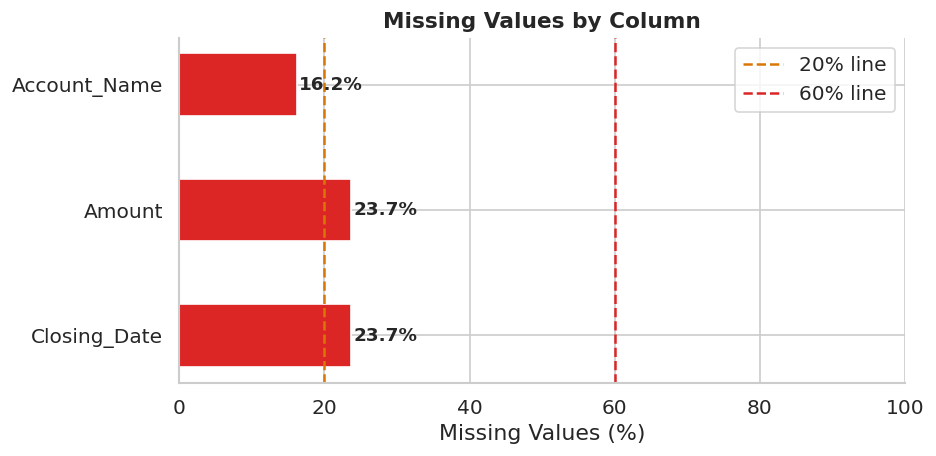

In [19]:
# Visualise missing values (only runs if there are any)
if df.isna().sum().sum() > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    
    cols_with_nulls = missing_report[missing_report['Missing'] > 0]['Column']
    pcts = missing_report[missing_report['Missing'] > 0]['Missing %']
    
    bars = ax.barh(cols_with_nulls, pcts,
                   color='#DC2626', edgecolor='white', height=0.5)
    
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Missing Values (%)')
    ax.set_title('Missing Values by Column', fontweight='bold', fontsize=13)
    ax.axvline(x=20, color='#D97706', linestyle='--', label='20% line')
    ax.axvline(x=60, color='#DC2626', linestyle='--', label='60% line')
    ax.legend()
    ax.set_xlim(0, 100)
    
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print("✅ No missing values — skipping chart.")


---
## Step 5 — Analyse the Target Column (Stage)

`Stage` is what we want our ML model to **predict**.  
Understanding how many deals are in each stage is the most important  
step in the entire EDA.

> **Why does this matter?**  
> If 90% of deals are "Won", a lazy model could predict "Won" every time  
> and be 90% accurate — but completely useless. We need to know if the  
> classes are balanced.


In [20]:
# Count deals in each Stage
stage_counts = df['Stage'].value_counts()
stage_pct    = df['Stage'].value_counts(normalize=True).mul(100).round(1)

stage_summary = pd.DataFrame({
    'Stage'      : stage_counts.index,
    'Count'      : stage_counts.values,
    'Percentage' : stage_pct.values,
}).reset_index(drop=True)

print("── Deal Stage Distribution ───────────────────────────────────")
display(stage_summary)

# Imbalance check
biggest  = stage_counts.max()
smallest = stage_counts.min()
ratio    = round(biggest / smallest, 1)

print(f"\nLargest class  : {stage_counts.idxmax()}  ({biggest:,} deals)")
print(f"Smallest class : {stage_counts.idxmin()}  ({smallest:,} deals)")
print(f"Imbalance ratio: {ratio}:1")

if ratio > 5:
    print("\n⚠️  SEVERE imbalance — we will need to handle this in Phase 2.")
elif ratio > 2:
    print("\n⚠️  MODERATE imbalance — consider class weighting in Phase 2.")
else:
    print("\n✅ Classes are reasonably balanced.")


── Deal Stage Distribution ───────────────────────────────────


,Stage,Count,Percentage
0,Won,4238,48.2
1,Lost,2473,28.1
2,Engaging,1589,18.1
3,Prospecting,500,5.7



Largest class  : Won  (4,238 deals)
Smallest class : Prospecting  (500 deals)
Imbalance ratio: 8.5:1

⚠️  SEVERE imbalance — we will need to handle this in Phase 2.


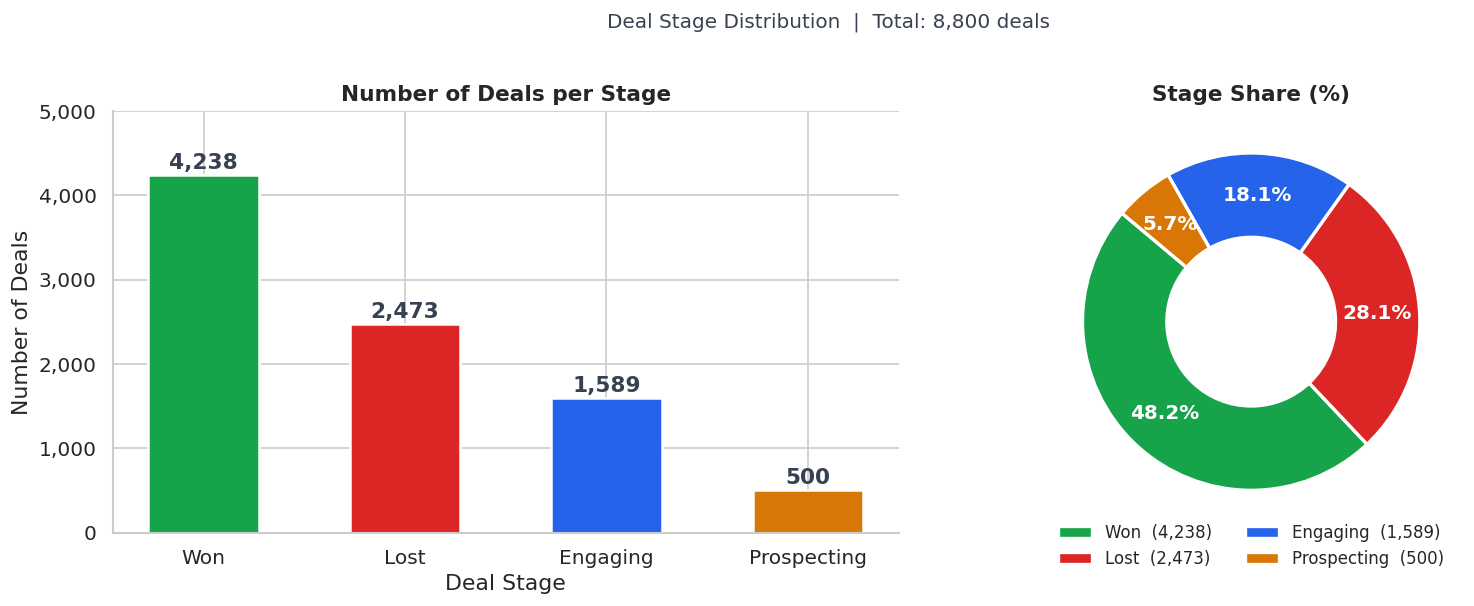

✅ Chart saved as 'stage_distribution.png'


In [21]:
# Chart 1: Bar chart — how many deals per stage?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: bar chart ───────────────────────────────────────────────
ax1 = axes[0]
stages = stage_summary['Stage'].tolist()
counts = stage_summary['Count'].tolist()
colors = [STAGE_COLOURS.get(s, '#94A3B8') for s in stages]

bars = ax1.bar(stages, counts, color=colors, edgecolor='white',
               linewidth=1.5, width=0.55)

# Add count label on top of each bar
for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{count:,}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#374151'
    )

ax1.set_title('Number of Deals per Stage', fontweight='bold', fontsize=13)
ax1.set_xlabel('Deal Stage')
ax1.set_ylabel('Number of Deals')
ax1.set_ylim(0, max(counts) * 1.18)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Right: donut chart ─────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

ax2.legend(
    wedges,
    [f"{s}  ({c:,})" for s, c in zip(stages, counts)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2, fontsize=10, frameon=False
)
ax2.set_title('Stage Share (%)', fontweight='bold', fontsize=13)

plt.suptitle(f'Deal Stage Distribution  |  Total: {sum(counts):,} deals',
             fontsize=12, y=1.01, color='#374151')
plt.tight_layout()
plt.savefig('stage_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'stage_distribution.png'")


---
## Step 6 — Analyse the Amount Column

`Amount` is our only numerical feature.  
We want to understand:
- What is the typical deal value?
- Are there extreme outliers?
- Does deal value differ between stages?


In [22]:
# Basic statistics for Amount
print("── Amount — Descriptive Statistics ──────────────────────────")
stats = df['Amount'].describe()
display(pd.DataFrame({'Statistic': stats.index, 'Value': stats.values.round(2)}))

print(f"\nSkewness : {df['Amount'].skew():.2f}  (>1 = right-skewed, many small deals + a few huge ones)")


── Amount — Descriptive Statistics ──────────────────────────


,Statistic,Value
0,count,6711.00
1,mean,1490.92
2,std,2320.67
3,min,0.00
4,25%,0.00
5,50%,472.00
6,75%,3225.00
7,max,30288.00



Skewness : 3.57  (>1 = right-skewed, many small deals + a few huge ones)


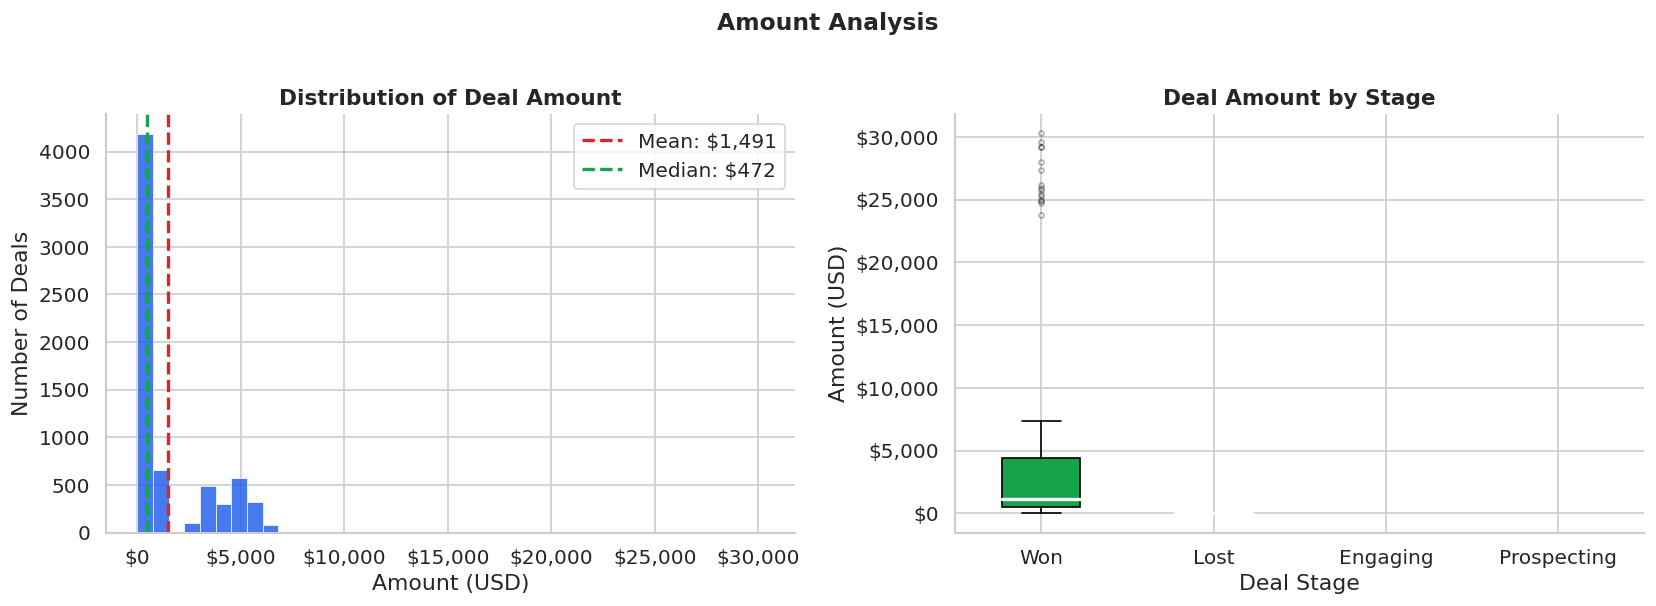

✅ Chart saved as 'amount_analysis.png'


In [23]:
# Chart 2: Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram ───────────────────────────────────────────────
ax1 = axes[0]
ax1.hist(df['Amount'].dropna(), bins=40,
         color='#2563EB', edgecolor='white', linewidth=0.5, alpha=0.85)
ax1.axvline(df['Amount'].mean(),   color='#DC2626', linestyle='--',
            linewidth=2, label=f"Mean: ${df['Amount'].mean():,.0f}")
ax1.axvline(df['Amount'].median(), color='#16A34A', linestyle='--',
            linewidth=2, label=f"Median: ${df['Amount'].median():,.0f}")
ax1.set_title('Distribution of Deal Amount', fontweight='bold', fontsize=13)
ax1.set_xlabel('Amount (USD)')
ax1.set_ylabel('Number of Deals')
ax1.legend()
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Right: boxplot ────────────────────────────────────────────────
ax2 = axes[1]
stage_order = [s for s in ['Won','Lost','Engaging','Prospecting']
               if s in df['Stage'].unique()]
colours_list = [STAGE_COLOURS.get(s, '#94A3B8') for s in stage_order]

bp = ax2.boxplot(
    [df[df['Stage'] == s]['Amount'].dropna() for s in stage_order],
    labels=stage_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', alpha=0.3, markersize=3),
)
for patch, colour in zip(bp['boxes'], colours_list):
    patch.set_facecolor(colour)

ax2.set_title('Deal Amount by Stage', fontweight='bold', fontsize=13)
ax2.set_xlabel('Deal Stage')
ax2.set_ylabel('Amount (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Amount Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('amount_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'amount_analysis.png'")


In [24]:
# Average amount per stage — simple but powerful insight
avg_by_stage = (df.groupby('Stage')['Amount']
                  .agg(['mean', 'median', 'min', 'max', 'count'])
                  .round(0)
                  .rename(columns={'mean':'Avg','median':'Median',
                                   'min':'Min','max':'Max','count':'Deals'}))

print("── Average Amount by Stage ───────────────────────────────────")
display(avg_by_stage.sort_values('Avg', ascending=False))


── Average Amount by Stage ───────────────────────────────────


,Avg,Median,Min,Max,Deals
Stage,,,,,
Won,2361.0,1117.0,38.0,30288.0,4238
Lost,0.0,0.0,0.0,0.0,2473
Engaging,NaN,NaN,NaN,NaN,0
Prospecting,NaN,NaN,NaN,NaN,0


---
## Step 7 — Analyse Owner Performance

`Owner_Name` tells us which sales rep handled each deal.  
We want to see who has the most deals and how their win rates compare.


In [25]:
# How many deals does each owner have?
owner_counts = df['Owner_Name'].value_counts()

print(f"Total unique owners: {df['Owner_Name'].nunique()}")
print(f"\n── Top 10 Owners by Deal Count ───────────────────────────────")
display(owner_counts.head(10).rename('Deal Count').to_frame())


Total unique owners: 30

── Top 10 Owners by Deal Count ───────────────────────────────


,Deal Count
Owner_Name,
Darcel Schlecht,747
Vicki Laflamme,451
Anna Snelling,448
Kary Hendrixson,438
Kami Bicknell,362
Versie Hillebrand,361
Zane Levy,349
Cassey Cress,346
Jonathan Berthelot,345


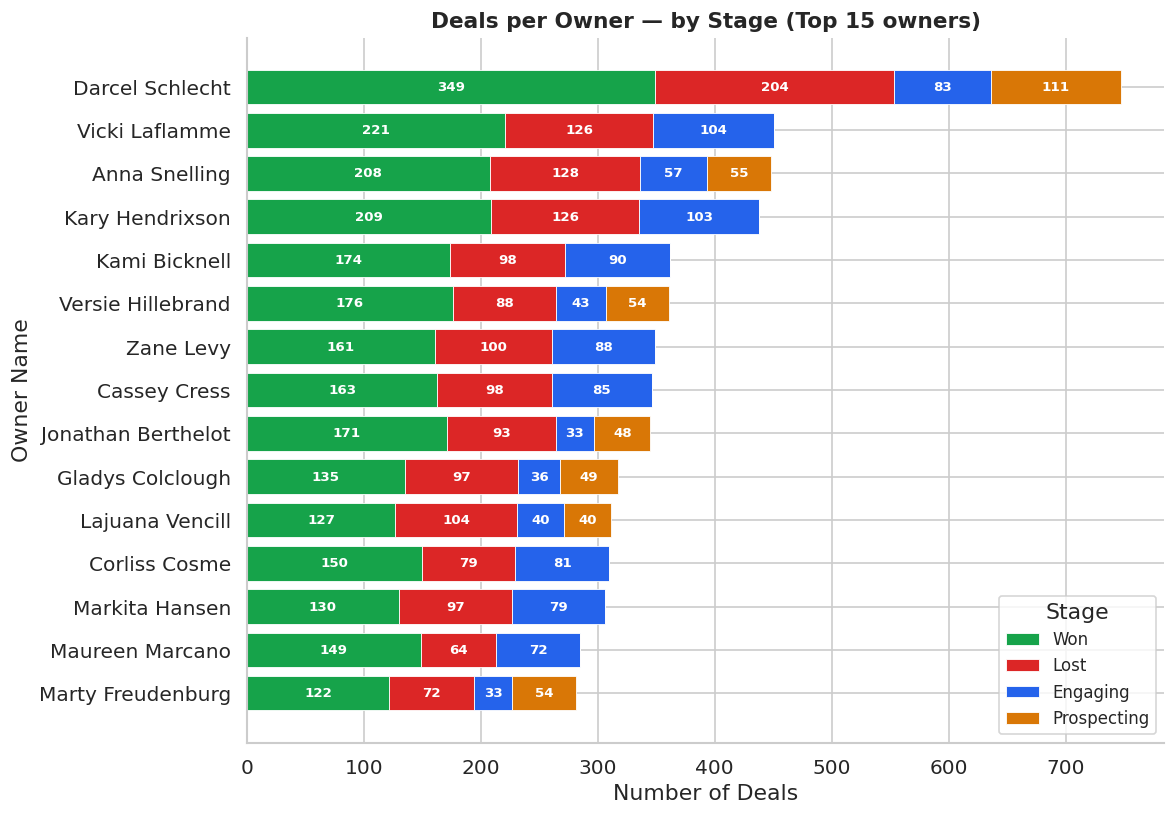

✅ Chart saved as 'owner_performance.png'


In [27]:
# Chart 3: Deals per owner, coloured by stage (stacked bar)
# Take top 15 owners by total deal count
top_owners = df['Owner_Name'].value_counts().head(15).index.tolist()
df_top = df[df['Owner_Name'].isin(top_owners)].copy()

# Pivot: rows = owners, columns = stages, values = deal counts
pivot = (df_top.groupby(['Owner_Name', 'Stage'])
               .size()
               .unstack(fill_value=0))

# Keep only stage columns that exist
stage_order = [s for s in ['Won','Lost','Engaging','Prospecting']
               if s in pivot.columns]
pivot = pivot[stage_order]

# Sort by total deals
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(10, 7))

left = np.zeros(len(pivot))
for stage in stage_order:
    if stage in pivot.columns:
        values = pivot[stage].values
        bars = ax.barh(pivot.index, values, left=left,
                       color=STAGE_COLOURS.get(stage, '#94A3B8'),
                       edgecolor='white', linewidth=0.5,
                       label=stage)
        # Add count labels inside bars where there's space
        for i, (v, l) in enumerate(zip(values, left)):
            if v > 5:
                ax.text(l + v/2, i, str(v),
                        ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        left = left + values

ax.set_title('Deals per Owner — by Stage (Top 15 owners)', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Deals')    
ax.set_ylabel('Owner Name')
ax.legend(loc='lower right', title='Stage', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('owner_performance.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'owner_performance.png'")


In [28]:
# Win rate per owner (% of deals that are 'Won')
win_rate = (df.groupby('Owner_Name')
              .apply(lambda x: (x['Stage'] == 'Won').sum() / len(x) * 100)
              .round(1)
              .rename('Win Rate %')
              .sort_values(ascending=False))

total_deals = df.groupby('Owner_Name').size().rename('Total Deals')
avg_amount  = df.groupby('Owner_Name')['Amount'].mean().round(0).rename('Avg Amount $')

owner_summary = pd.concat([total_deals, win_rate, avg_amount], axis=1)
owner_summary = owner_summary.sort_values('Win Rate %', ascending=False)

print("── Owner Performance Summary ─────────────────────────────────")
display(owner_summary.head(15))


── Owner Performance Summary ─────────────────────────────────


,Total Deals,Win Rate %,Avg Amount $
Owner_Name,,,
Reed Clapper,237,65.4,1850.0
Garret Kinder,123,61.0,1608.0
Donn Cantrell,275,57.5,1621.0
Hayden Neloms,202,53.0,1790.0
Cecily Lampkin,203,52.7,1436.0
Maureen Marcano,285,52.3,1645.0
James Ascencio,267,50.6,2007.0
Wilburn Farren,110,50.0,1995.0
Moses Frase,260,49.6,1062.0


---
## Step 8 — Analyse Account Names

`Account_Name` is the company/client. High-cardinality — there may be  
hundreds of unique accounts. We look at the top accounts and their stage spread.


In [30]:
print(f"Total unique accounts: {df['Account_Name'].nunique()}")
print()

# Top 15 accounts by deal count
top_accounts = df['Account_Name'].value_counts().head(20)
print("── Top 15 Accounts by Deal Count ─────────────────────────────")
display(top_accounts.rename('Deal Count').to_frame())


Total unique accounts: 85

── Top 15 Accounts by Deal Count ─────────────────────────────


,Deal Count
Account_Name,
Hottechi,200
Kan-code,196
Konex,178
Condax,170
Dontechi,129
Codehow,121
Isdom,119
Treequote,116
Inity,113


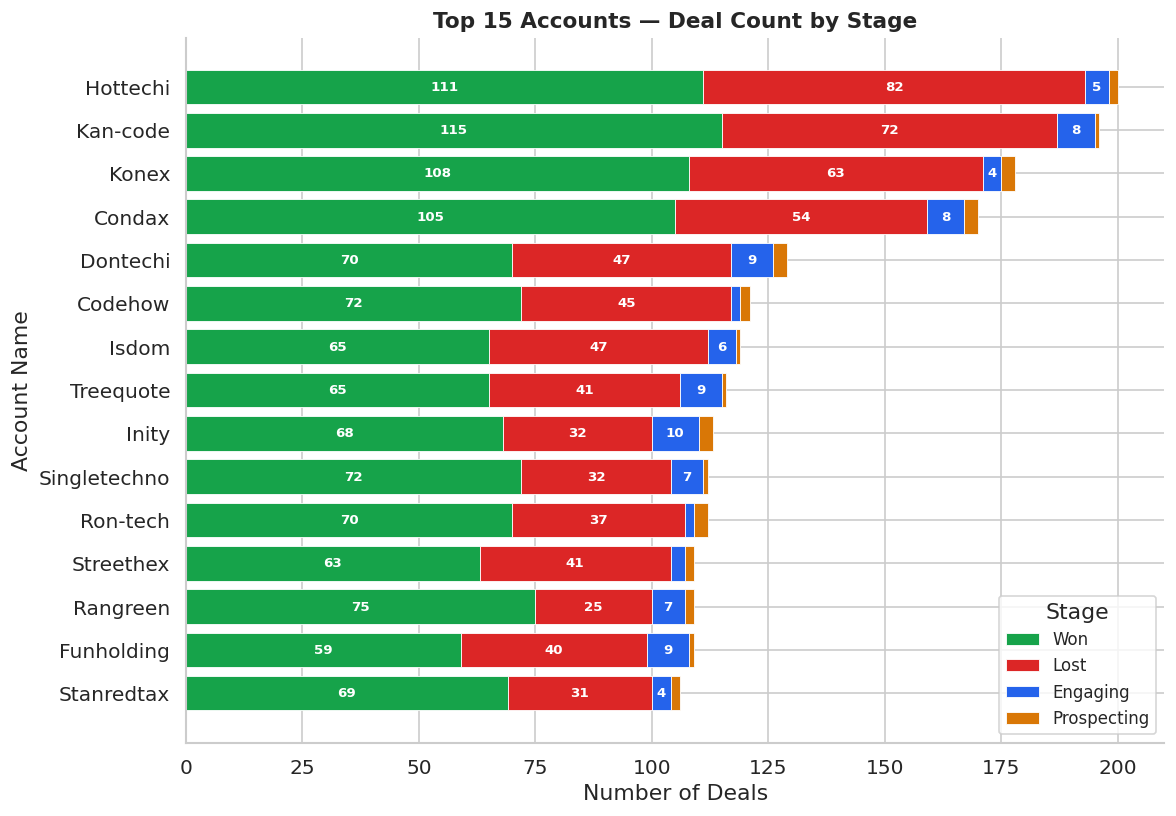

✅ Chart saved as 'account_analysis.png'


In [31]:
# Chart 4: Top 15 accounts coloured by stage
top_acc_names = df['Account_Name'].value_counts().head(15).index.tolist()
df_acc = df[df['Account_Name'].isin(top_acc_names)].copy()

pivot_acc = (df_acc.groupby(['Account_Name','Stage'])
                   .size()
                   .unstack(fill_value=0))

stage_order = [s for s in ['Won','Lost','Engaging','Prospecting']
               if s in pivot_acc.columns]
pivot_acc = pivot_acc[stage_order]
pivot_acc = pivot_acc.loc[pivot_acc.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(10, 7))
left = np.zeros(len(pivot_acc))

for stage in stage_order:
    if stage in pivot_acc.columns:
        vals = pivot_acc[stage].values
        ax.barh(pivot_acc.index, vals, left=left,
                color=STAGE_COLOURS.get(stage, '#94A3B8'),
                edgecolor='white', linewidth=0.5,
                label=stage)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v > 3:
                ax.text(l + v/2, i, str(v),
                        ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        left = left + vals

ax.set_title('Top 15 Accounts — Deal Count by Stage', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Deals')
ax.set_ylabel('Account Name')
ax.legend(loc='lower right', title='Stage', fontsize=10)

plt.tight_layout()
plt.savefig('account_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'account_analysis.png'")


---
## Step 9 — Analyse Closing Dates

`Closing_Date` is a date column. We can extract useful features from it:
- **Year** — which year are most deals closing?
- **Month** — is there a seasonal pattern?
- **Day of Week** — do deals close more on certain days?


In [32]:
# Extract date-based features
df['Year']         = df['Closing_Date'].dt.year
df['Month']        = df['Closing_Date'].dt.month
df['Month_Name']   = df['Closing_Date'].dt.strftime('%b')   # Jan, Feb, ...
df['Day_of_Week']  = df['Closing_Date'].dt.day_name()
df['Quarter']      = df['Closing_Date'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})

print("✅ Date features extracted: Year, Month, Month_Name, Day_of_Week, Quarter")
print()
print(df[['Closing_Date','Year','Month','Month_Name','Day_of_Week','Quarter']].head(8))


✅ Date features extracted: Year, Month, Month_Name, Day_of_Week, Quarter

  Closing_Date    Year  Month Month_Name Day_of_Week Quarter
0   2017-03-01  2017.0    3.0        Mar   Wednesday      Q1
1   2017-03-11  2017.0    3.0        Mar    Saturday      Q1
2   2017-03-07  2017.0    3.0        Mar     Tuesday      Q1
3   2017-03-09  2017.0    3.0        Mar    Thursday      Q1
4   2017-03-02  2017.0    3.0        Mar    Thursday      Q1
5   2017-03-01  2017.0    3.0        Mar   Wednesday      Q1
6   2017-03-02  2017.0    3.0        Mar    Thursday      Q1
7   2017-03-07  2017.0    3.0        Mar     Tuesday      Q1


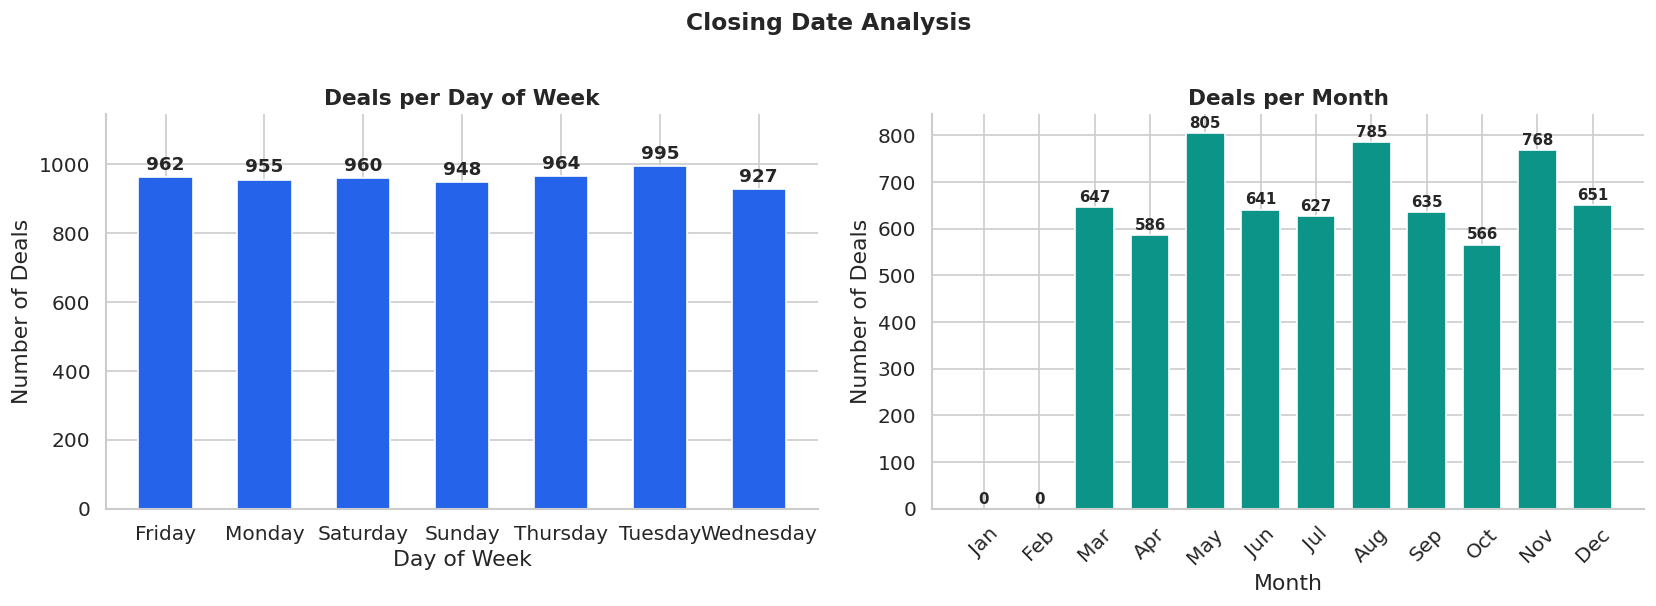

✅ Chart saved as 'date_analysis.png'


In [35]:
# Chart 5: Deals per year and per month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: deals per year ──────────────────────────────────────────
ax1 = axes[0]
year_counts = df['Day_of_Week'].value_counts().sort_index()
bars = ax1.bar(year_counts.index.astype(str), year_counts.values,
               color='#2563EB', edgecolor='white', width=0.55)
for bar, count in zip(bars, year_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Deals per Day of Week', fontweight='bold', fontsize=13)
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Number of Deals')
ax1.set_ylim(0, year_counts.max() * 1.15)

# ── Right: deals per month ─────────────────────────────────────────
ax2 = axes[1]
month_order    = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']
month_counts   = df['Month_Name'].value_counts().reindex(month_order, fill_value=0)
bars2 = ax2.bar(month_counts.index, month_counts.values,
                color='#0D9488', edgecolor='white', width=0.7)
for bar, count in zip(bars2, month_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Deals per Month', fontweight='bold', fontsize=13)
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Deals')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Closing Date Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('date_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'date_analysis.png'")


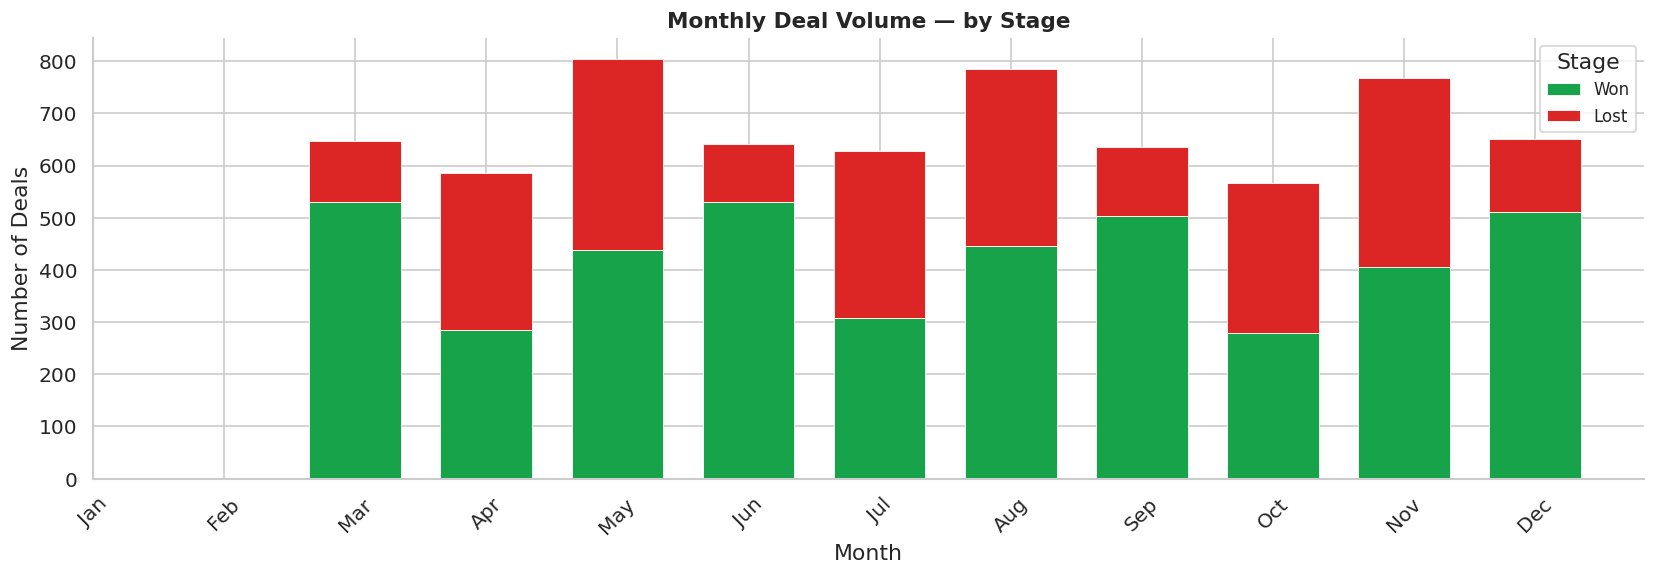

✅ Chart saved as 'monthly_stage_breakdown.png'


In [36]:
# Chart 6: Deals per month coloured by Stage (heatmap style)
pivot_month = (df.groupby(['Month','Stage'])
                 .size()
                 .unstack(fill_value=0))

stage_order = [s for s in ['Won','Lost','Engaging','Prospecting']
               if s in pivot_month.columns]
pivot_month = pivot_month[stage_order]

fig, ax = plt.subplots(figsize=(14, 5))
left = np.zeros(len(pivot_month))

for stage in stage_order:
    if stage in pivot_month.columns:
        vals = pivot_month[stage].values
        ax.bar(pivot_month.index, vals, bottom=left,
               color=STAGE_COLOURS.get(stage, '#94A3B8'),
               edgecolor='white', linewidth=0.5,
               label=stage, width=0.7)
        left = left + vals

ax.set_title('Monthly Deal Volume — by Stage', fontweight='bold', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Deals')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.legend(title='Stage', fontsize=10)

plt.tight_layout()
plt.savefig('monthly_stage_breakdown.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'monthly_stage_breakdown.png'")


---
## Step 10 — Correlation Check

With only one numerical column (`Amount`) we can't build a full correlation  
matrix yet. Instead, we encode the Stage as a number and see if there's any  
linear relationship between Amount and Stage.

> **Note:** After feature engineering in Phase 2, we'll have more numerical  
> features and will revisit this.


── Correlation Table ─────────────────────────────────────────


,Amount,Month,Year,Stage_Num
Amount,1.000,-0.004,NaN,0.491
Month,-0.004,1.000,NaN,-0.013
Year,NaN,NaN,NaN,NaN
Stage_Num,0.491,-0.013,NaN,1.000


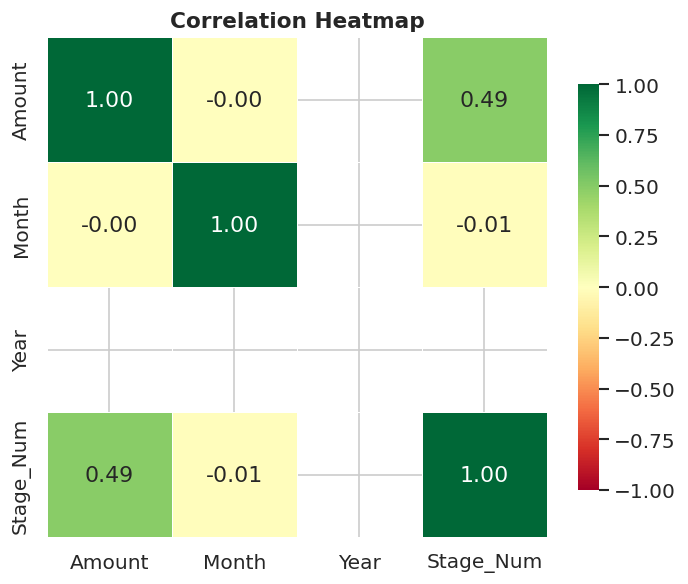

✅ Chart saved as 'correlation.png'


In [37]:
# Encode Stage as a number temporarily, just for this chart
stage_map = {'Won': 3, 'Engaging': 2, 'Prospecting': 1, 'Lost': 0}
df['Stage_Num'] = df['Stage'].map(stage_map)

corr_df = df[['Amount', 'Month', 'Year', 'Stage_Num']].dropna()

print("── Correlation Table ─────────────────────────────────────────")
display(corr_df.corr().round(3))

fig, ax = plt.subplots(figsize=(6, 5))
corr_matrix = corr_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'correlation.png'")

# Clean up the temporary column
df.drop(columns=['Stage_Num'], inplace=True)


---
## Step 11 — EDA Summary

Let's print a clean summary of everything we found.  
This will guide all our decisions in **Phase 2 (Preprocessing)**.


In [39]:
# Auto-generate the full EDA summary
print("=" * 60)
print("  EDA SUMMARY REPORT — AI CRM Brain")
print("=" * 60)

# Dataset basics
print(f"\n📦  DATASET")
print(f"    Rows    : {len(df):,}")
print(f"    Columns : {df.shape[1]}")

# Missing values
total_missing = df[['Owner_Name','Account_Name','Stage','Amount','Closing_Date']].isna().sum().sum()
print(f"\n❓  MISSING VALUES")
if total_missing == 0:
    print("    ✅ No missing values found.")
else:
    print(f"    ⚠️  {total_missing} missing cells found — see Step 4 for details.")

# Target
print(f"\n🎯  TARGET COLUMN: Stage")
for stage, count in df['Stage'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 4)
    print(f"    {stage:<15} {count:>5,}  ({pct:>5.1f}%)  {bar}")

print(f"\n    Imbalance ratio: {ratio}:1")
if ratio > 5:
    print("    → Action needed: Use class_weight='balanced' in Phase 4")
elif ratio > 2:
    print("    → Moderate: Consider class_weight='balanced' in Phase 4")
else:
    print("    → Balanced: No special handling needed")

# Amount
print(f"\n💰  AMOUNT (USD)")
print(f"    Min    : ${df['Amount'].min():>10,.0f}")
print(f"    Median : ${df['Amount'].median():>10,.0f}")
print(f"    Mean   : ${df['Amount'].mean():>10,.0f}")
print(f"    Max    : ${df['Amount'].max():>10,.0f}")
print(f"    Skew   : {df['Amount'].skew():>10.2f}  {'(right-skewed → use log transform in Phase 2)' if df['Amount'].skew() > 1 else ''}")

# Owners & Accounts
print(f"\n👤  OWNERS")
print(f"    Unique owners   : {df['Owner_Name'].nunique()}")
print(f"    Top performer   : {df['Owner_Name'].value_counts().idxmax()}  ({df['Owner_Name'].value_counts().max()} deals)")

print(f"\n🏢  ACCOUNTS")
print(f"    Unique accounts : {df['Account_Name'].nunique()}")
print(f"    Top account     : {df['Account_Name'].value_counts().idxmax()}  ({df['Account_Name'].value_counts().max()} deals)")

# Dates
print(f"\n📅  DATES")
print(f"    Range : {df['Closing_Date'].min().date()}  →  {df['Closing_Date'].max().date()}")
print(f"    Span  : {(df['Closing_Date'].max() - df['Closing_Date'].min()).days:,} days")

print(f"\n📊  CHARTS SAVED")
charts = ['stage_distribution.png','amount_analysis.png','owner_performance.png',
          'account_analysis.png','date_analysis.png',
          'monthly_stage_breakdown.png','correlation.png']
for c in charts:
    print(f"    ✅ {c}")

print("\n" + "=" * 60)
print("  Phase 1 Complete — Ready for Phase 2: Preprocessing")
print("=" * 60)


  EDA SUMMARY REPORT — AI CRM Brain

📦  DATASET
    Rows    : 8,800
    Columns : 10

❓  MISSING VALUES
    ⚠️  5603 missing cells found — see Step 4 for details.

🎯  TARGET COLUMN: Stage
    Won             4,238  ( 48.2%)  ████████████
    Lost            2,473  ( 28.1%)  ███████
    Engaging        1,589  ( 18.1%)  ████
    Prospecting       500  (  5.7%)  █

    Imbalance ratio: 8.5:1
    → Action needed: Use class_weight='balanced' in Phase 4

💰  AMOUNT (USD)
    Min    : $         0
    Median : $       472
    Mean   : $     1,491
    Max    : $    30,288
    Skew   :       3.57  (right-skewed → use log transform in Phase 2)

👤  OWNERS
    Unique owners   : 30
    Top performer   : Darcel Schlecht  (747 deals)

🏢  ACCOUNTS
    Unique accounts : 85
    Top account     : Hottechi  (200 deals)

📅  DATES
    Range : 2017-03-01  →  2017-12-31
    Span  : 305 days

📊  CHARTS SAVED
    ✅ stage_distribution.png
    ✅ amount_analysis.png
    ✅ owner_performance.png
    ✅ account_analysis

---

## ✅ Phase 1 Complete!

### What We Found

| Area | Finding | Phase 2 Action |
|---|---|---|
| **Missing Values** | Run cell to check | Impute or drop if found |
| **Stage (Target)** | 4 classes, possible imbalance | Use `class_weight='balanced'` |
| **Amount** | Single numerical feature, likely right-skewed | Apply log transform |
| **Owner_Name** | Categorical, multiple owners | Encode (OneHot or Frequency) |
| **Account_Name** | High cardinality | Frequency encoding or drop |
| **Closing_Date** | Date — extract Month, Year, Quarter | Feature engineering |

---

### Charts Produced

| File | What it shows |
|---|---|
| `stage_distribution.png` | How many deals per stage |
| `amount_analysis.png` | Deal value distribution + by stage |
| `owner_performance.png` | Which reps have the most deals |
| `account_analysis.png` | Top accounts by deal count |
| `date_analysis.png` | Deals per year and per month |
| `monthly_stage_breakdown.png` | Stage breakdown by month |
| `correlation.png` | Feature correlations |

---

> **Ready for the next step?**  
> Tell the AI: **"Continue to Phase 2 — Data Preprocessing"**
